# 08 — Dashboard: European Power Market Explorer

**Evaluation: Working artefact + Why this matters** — An interactive visualization to explore and explain market dynamics.

**Why this matters:** InCommodities and market participants need to interpret complex signals in real time. This dashboard provides a starting point to explore supply, demand, prices, and cross-border flows—extensible to live data.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from src.data_loader import (
    load_spot_price,
    load_all_spot_prices,
    load_total_load,
    load_generation_pivot,
    load_flows_into,
    load_weather,
)

## Static dashboard (sample week)

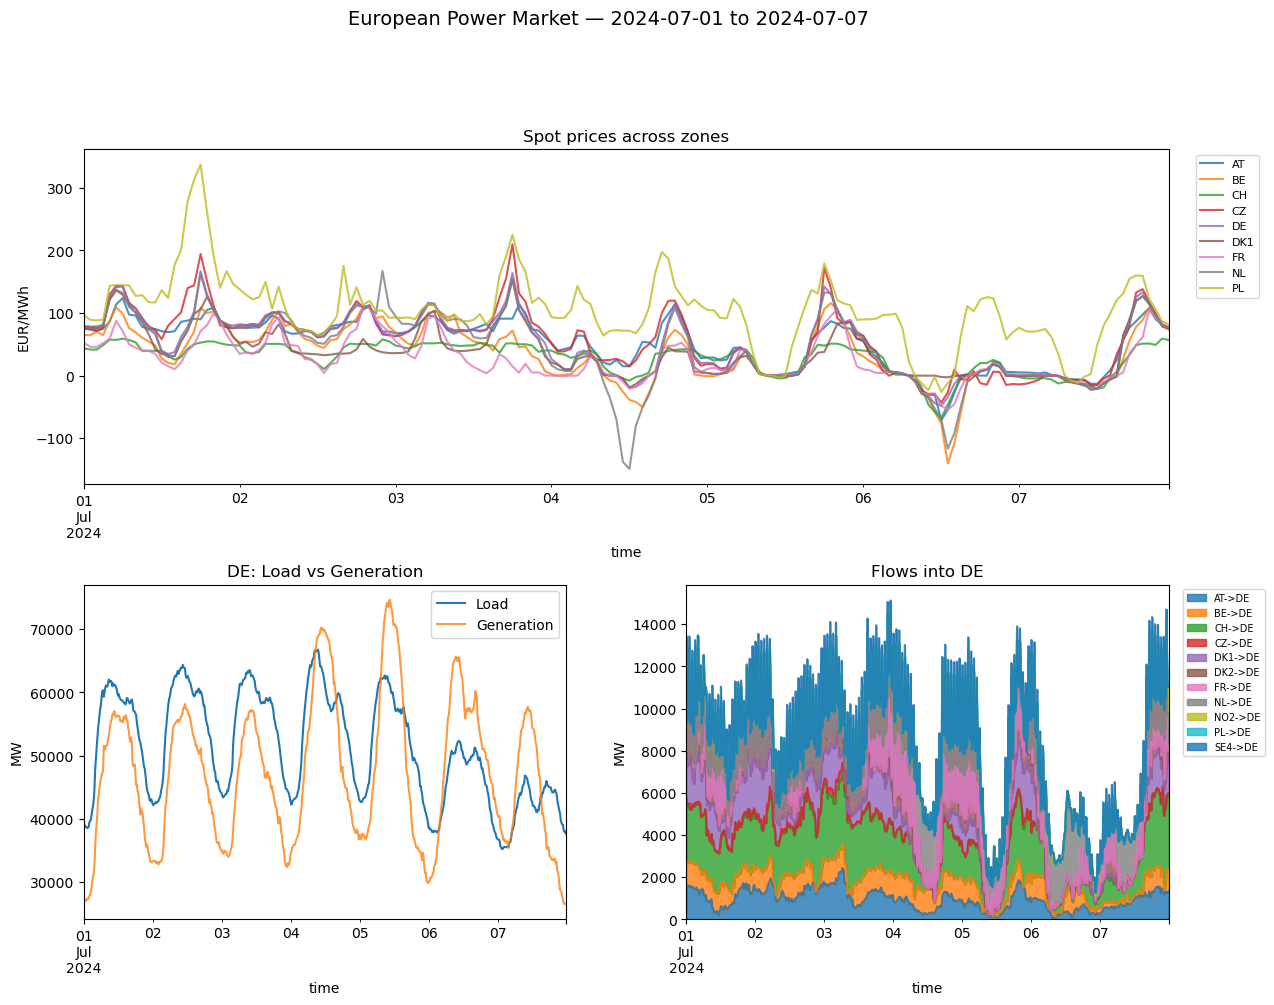

In [2]:
def build_dashboard(start: str = "2024-07-01", end: str = "2024-07-07", zone: str = "DE"):
    """Build a 4-panel dashboard for a given date range."""
    fig = plt.figure(figsize=(14, 10))
    gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.25)

    # 1. Spot prices (all zones)
    ax1 = fig.add_subplot(gs[0, :])
    prices = load_all_spot_prices()
    if isinstance(prices.columns, pd.MultiIndex):
        prices.columns = prices.columns.get_level_values(0)
    sample = prices.loc[start:end]
    sample.plot(ax=ax1, alpha=0.8)
    ax1.set_ylabel("EUR/MWh")
    ax1.set_title("Spot prices across zones")
    ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

    # 2. DE: Load + Generation
    ax2 = fig.add_subplot(gs[1, 0])
    load = load_total_load(zone)
    gen = load_generation_pivot(zone)
    gen["total"] = gen.sum(axis=1)
    l_sample = load.loc[start:end]
    g_sample = gen.loc[start:end]
    l_sample["load"].plot(ax=ax2, label="Load", color="C0")
    g_sample["total"].plot(ax=ax2, label="Generation", color="C1", alpha=0.8)
    ax2.set_ylabel("MW")
    ax2.set_title(f"{zone}: Load vs Generation")
    ax2.legend()

    # 3. DE: Flows in
    ax3 = fig.add_subplot(gs[1, 1])
    flows = load_flows_into(zone)
    pivot = flows.pivot(index="time", columns="zone", values="value (MW)")
    pivot.index = pd.to_datetime(pivot.index, utc=True)
    f_sample = pivot.loc[start:end]
    f_sample.plot.area(ax=ax3, stacked=True, alpha=0.8)
    ax3.set_ylabel("MW")
    ax3.set_title(f"Flows into {zone}")
    ax3.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)

    fig.suptitle(f"European Power Market — {start} to {end}", fontsize=14, y=1.02)
    return fig

fig = build_dashboard()
plt.show()

## Export as HTML (for sharing)

In [3]:
# Save figure for presentation
fig = build_dashboard()
fig.savefig("../outputs/dashboard_sample.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved to outputs/dashboard_sample.png")

Saved to outputs/dashboard_sample.png
